# EX YU Music Analysis — Finalni pregled nalaza

**Analiza podataka u promeni trendova u EX YU muzici pomoću LLM modela**

---

Ovaj notebook učitava već generisane izveštaje i slike (Faze 4–6 projekta)
i prikazuje ih redom, sa kratkim objašnjenjem šta svaki nalaz znači.
Ne ponavlja analize iznova — koristi gotove rezultate, i spreman je za
prezentaciju mentoru ili odbranu.

### Sadržaj

1. [Priprema okruženja](#1)
2. [Pregled korpusa](#2)
3. [TF-IDF — karakteristične reči](#3)
4. [Leksička raznovrsnost (TTR vs. MATTR)](#4)
5. [Sentiment analiza](#5)
6. [Tematsko modelovanje — LDA](#6)
7. [BERTopic i klasterizacija](#7)
8. [LLM validacija — Cohen's kappa](#8)
9. [Obrasci neslaganja LLM/ljudi](#9)
10. [Analiza po dekadama](#10)
11. [Rezime ključnih nalaza](#11)

---

**Napomena pre pokretanja:** notebook očekuje da svi CSV izveštaji i PNG
slike već postoje u `data/` i `results/` (tj. da su skripte iz Faza 2–6
već pokrenute bar jednom). Pokreni sve ćelije redom: `Kernel → Restart & Run All`.

<a id="1"></a>
## 1. Priprema okruženja

Učitavamo putanje iz centralne konfiguracije (`config/config.py`) — isto
mesto koje koristi ceo pipeline, da ne bismo dupli­rale podešavanja.

In [2]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Dodaj koren projekta u putanju, da uvoz config-a radi bez obzira
# odakle je Jupyter pokrenut
sys.path.append(str(Path.cwd()))

from config.config import PROCESSED_DATA_DIR, REPORTS_DIR, FIGURES_DIR, GOLD_STANDARD_DIR

pd.set_option("display.max_colwidth", 60)
print("✓ Putanje učitane")
print("✓ Radni folder:", Path.cwd())

✓ Putanje učitane
✓ Radni folder: C:\Users\ThinkPad\Desktop\VestackaInteligencija\Master rad\ex-yu-music-analysis\notebooks


<a id="2"></a>
## 2. Pregled korpusa

Osnovne brojke pre bilo kakve analize — koliko pesama, izvođača, i kako
je korpus raspoređen po periodu i žanru. Ovo je izlaz Faze 3
(preprocessing) — korpus filtriran za analizu, bez pesama na stranim
jezicima.

In [3]:
corpus = pd.read_csv(PROCESSED_DATA_DIR / "corpus_analysis_ready.csv")

print(f"Ukupno pesama u analizi:  {len(corpus)}")
print(f"Broj izvođača:            {corpus['artist'].nunique()}")

Ukupno pesama u analizi:  4084
Broj izvođača:            77


In [4]:
print("Raspodela po periodu:")
display(corpus["period"].value_counts())

print("\nRaspodela po žanru:")
display(corpus["genre"].value_counts())

Raspodela po periodu:


period
sfrj          2275
tranzicija    1194
savremeno      615
Name: count, dtype: int64


Raspodela po žanru:


genre
pop                    1569
turbo_folk              973
narodna_narodnjacka     807
rok                     513
novi_talas              142
hip_hop_rep              68
trep                      8
ostalo                    4
Name: count, dtype: int64

> **Tumačenje:** SFRJ period ima najviše pesama jer pokriva najduži
> vremenski raspon (31 godina). Pop, turbo-folk i narodna/narodnjačka
> dominiraju žanrovski — trep je najslabije zastupljen (poznato
> ograničenje izvora podataka, detaljno objašnjeno u README-u).

<a id="3"></a>
## 3. TF-IDF — karakteristične reči

**Pristup:** svaki period (i odvojeno, svaki žanr) tretiran je kao JEDAN
veliki "dokument" — TF-IDF preko ovih grupnih dokumenata pokazuje reči
KARAKTERISTIČNE za tu grupu (česte unutra, retke van nje), ne samo
najčešće reči uopšte.

In [5]:
# Top 10 karakterističnih reči po periodu
tfidf_period = pd.read_csv(REPORTS_DIR / "tfidf_top_reci_period.csv")

for period in tfidf_period["grupa"].unique():
    top10 = tfidf_period[tfidf_period["grupa"] == period].head(10)
    print(f"{period.upper():12} {', '.join(top10['rec'])}")

SAVREMENO    ljubav, srce, voliti, nemati, dan, noć, drugi, videti, život, dobro
SFRJ         ljubav, dan, srce, noć, san, nemati, voliti, život, drugi, oko
TRANZICIJA   ljubav, srce, nemati, voliti, život, drugi, noć, dan, gde, oko


In [6]:
# Top 10 karakterističnih reči po žanru
tfidf_genre = pd.read_csv(REPORTS_DIR / "tfidf_top_reci_genre.csv")

for genre in tfidf_genre["grupa"].unique():
    top10 = tfidf_genre[tfidf_genre["grupa"] == genre].head(10)
    print(f"{genre:22} {', '.join(top10['rec'])}")

hip_hop_rep            dan, voliti, što, videti, ljubav, reći, život, daleko, nemati, dobro
narodna_narodnjacka    srce, ljubav, život, nemati, drugi, voliti, tuga, sreća, dan, noć
novi_talas             nemati, videti, dan, želeti, grad, gledati, devojka, gde, više, vreme
ostalo                 voleti, praštati, mama, čekati, ljubav, svadba, srećan, pesma, uvek, san
pop                    ljubav, srce, noć, san, dan, nemati, život, voliti, oko, gde
rok                    dan, noć, nemati, vreme, kazati, ljubav, srce, malo, star, reći
trep                   gaditi, ah, ići, umeti, grešiti, delija, daleko, deli, jako, dam
turbo_folk             ljubav, srce, nemati, noć, život, drugi, voliti, tuga, dan, više


> **Tumačenje:** na prvih 10 mesta sve grupe deluju slično (ljubav,
> srce dominiraju svuda) — popularna muzika je dominantno o ljubavi,
> bez obzira na period/žanr. Prava razlika izranja tek na rangovima
> 11–20 (videti `results/reports/tfidf_top_reci_*.csv` za ceo spisak) —
> npr. "kokain"/"ortak" za hip-hop, "duša"/"suza" za narodnu muziku.

<a id="4"></a>
## 4. Leksička raznovrsnost (TTR vs. MATTR)

**TTR** (type-token ratio) = broj jedinstvenih reči / ukupan broj reči —
osetljiv na dužinu teksta. **MATTR** (moving-average TTR) računa TTR u
pokretnom prozoru fiksne dužine — ne zavisi od dužine teksta, pa je
pouzdaniji za poređenje pesama različite dužine.

In [7]:
lexdiv = pd.read_csv(REPORTS_DIR / "lexical_diversity_by_period.csv", index_col=0)
display(lexdiv)

,ttr,mattr,fk_grade
period,,,
savremeno,0.618,0.807,6.802
sfrj,0.673,0.782,7.290
tranzicija,0.647,0.785,6.886


> **Ključan nalaz:** TTR i MATTR daju **suprotne** zaključke o tome
> koji je period "raznovrsniji"! Sirovi TTR opada kroz periode
> (0.673→0.647→0.618), ali MATTR raste (0.782→0.785→0.807). MATTR je
> pouzdaniji — savremeni period je lokalno raznovrsniji po rečima, iako
> starije (duže) SFRJ pesme "izgledaju" raznovrsnije po sirovom TTR-u
> samo zbog svoje dužine.

<a id="5"></a>
## 5. Sentiment analiza

Leksikonski pristup (ručno sastavljen rečnik pozitivnih/negativnih reči,
pošto ne postoji standardizovan sentiment leksikon za srpski/hrvatski).

In [8]:
sentiment = pd.read_csv(REPORTS_DIR / "sentiment_by_period.csv", index_col=0)
display(sentiment)

,negativno,neutralno,pozitivno
period,,,
savremeno,0.322,0.236,0.442
sfrj,0.261,0.251,0.488
tranzicija,0.310,0.247,0.443


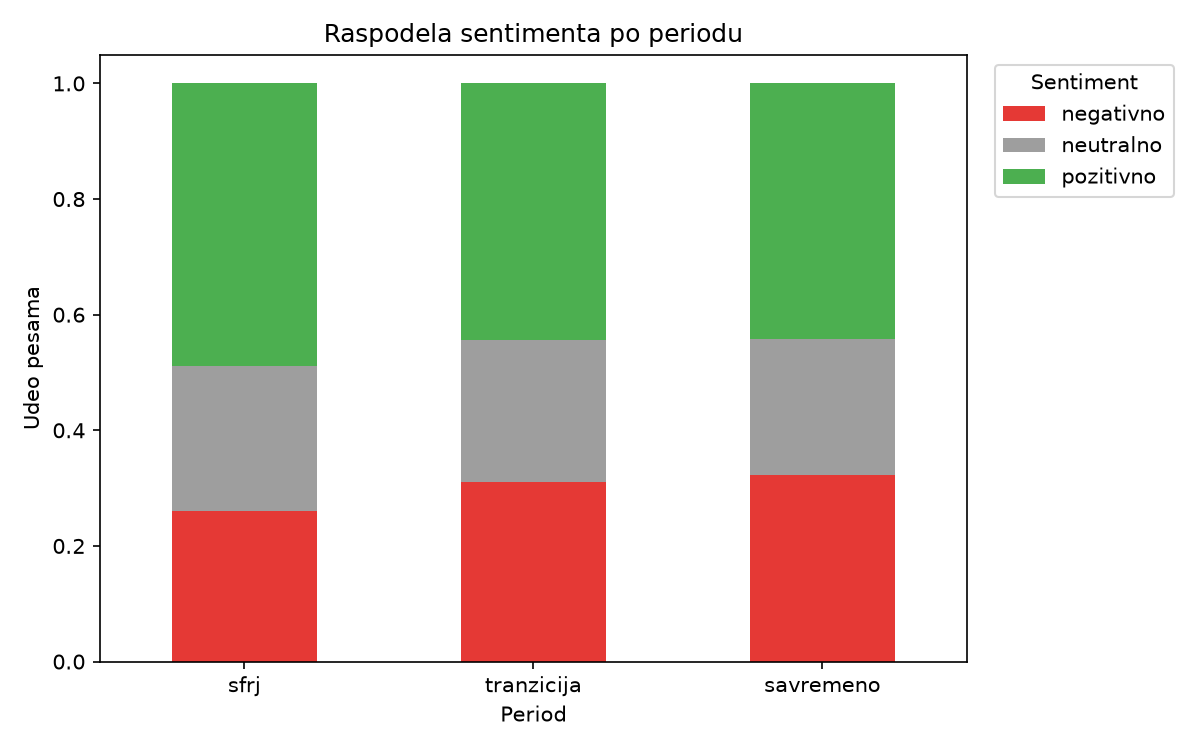

In [9]:
display(Image(filename=str(FIGURES_DIR / "sentiment_trend.png")))

> **Tumačenje:** blag, ali dosledan trend — SFRJ period ima najviše
> pozitivnih pesama (~49%), tranzicija i savremeno su nešto negativnije
> obojeni. Razlike su blage, ne dramatične, ali smer je konzistentan
> kroz sve tri grupe.

<a id="6"></a>
## 6. Tematsko modelovanje — LDA

Jedan LDA model treniran na CELOM korpusu (ne poseban po grupi) — ovo
obezbeđuje da sve pesme dele isti "prostor tema", pa je zastupljenost
tema po periodu/žanru smisleno uporediva.

In [10]:
# Top reči po svakoj od 10 automatski otkrivenih tema
topic_words = pd.read_csv(REPORTS_DIR / "lda_topic_words.csv")
display(topic_words)

,tema,top_reci
0,0,"ljubav, doći, noć, vreme, ruka, san, piti, ljubiti, staj..."
1,1,"voliti, kazati, tako, zašto, mnogo, život, srce, duša, ž..."
2,2,"vino, dolar, noć, milion, videti, gde, malo, oko, tamo, ..."
3,3,"ljubav, dan, voliti, što, nemati, reći, oprostiti, bol, ..."
4,4,"ići, gde, vreme, ljubav, krv, kriv, drugi, tuga, veco, duša"
5,5,"gde, majka, dan, voditi, ljubav, put, star, uvek, život,..."
6,6,"riba, tako, mali, ići, žena, drugi, malo, videti, srce, ..."
7,7,"život, dobro, brat, tu, što, nemati, kraj, dan, videti, ..."
8,8,"srce, nemati, daleko, oko, suza, vratiti, ljubav, više, ..."
9,9,"buditi, tu, mali, što, kazati, misliti, nikad, noć, grad..."


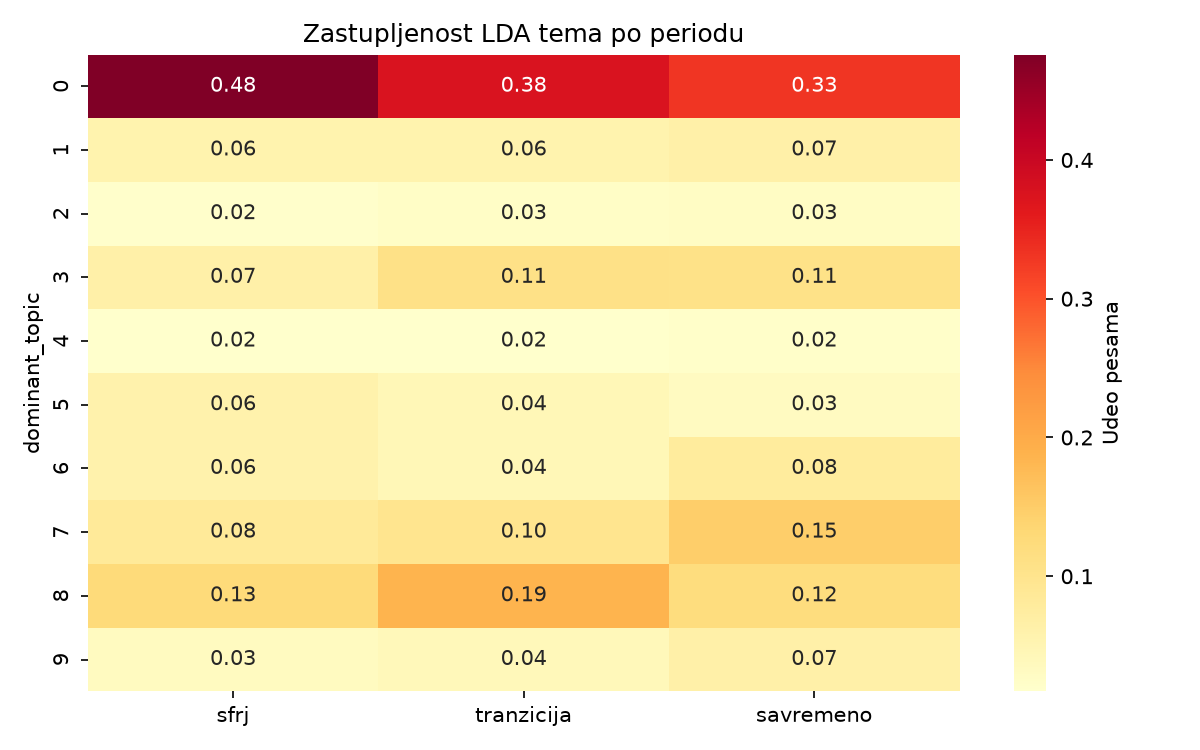

In [11]:
display(Image(filename=str(FIGURES_DIR / "lda_topics_by_period_heatmap.png")))

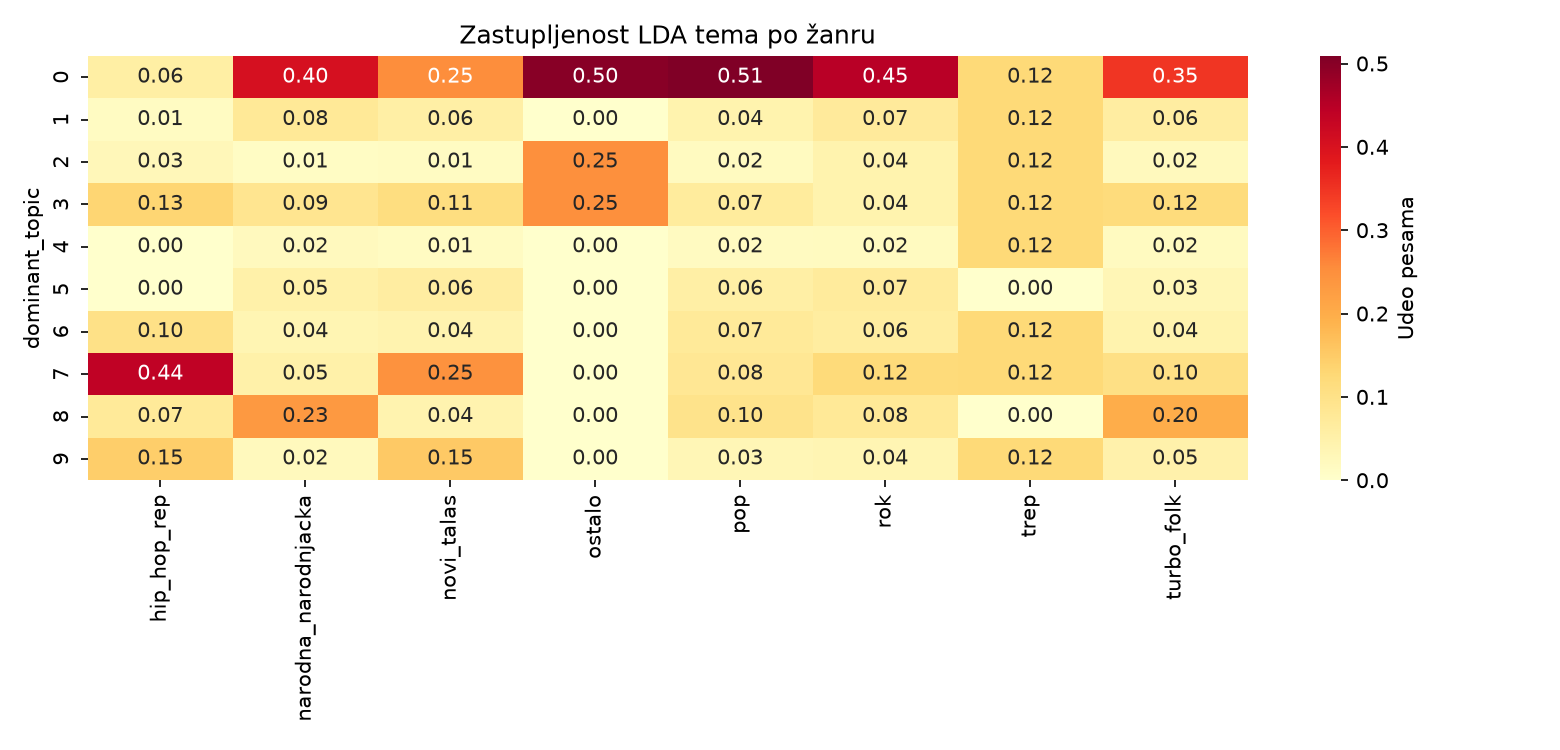

In [12]:
display(Image(filename=str(FIGURES_DIR / "lda_topics_by_genre_heatmap.png")))

> **Ključan nalaz:** Tema 7 ("život, brat, kraj") je upadljivo
> dominantna baš u hip-hop/rep žanru (44%), dok je svuda drugde
> jednocifrena — jasan, prepoznatljiv žanrovski obrazac. Tema 0
> (opšta ljubavna tematika) opada kroz periode (0.48→0.38→0.33),
> dok teme vezane za savremenu urbanu kulturu rastu.

<a id="7"></a>
## 7. BERTopic i K-means klasterizacija

Za razliku od LDA (bag-of-words), BERTopic koristi semantičke
embeddings (numeričke reprezentacije ZNAČENJA teksta) — hvata teme koje
LDA ne vidi, jer ne zavisi od zajedničkog pojavljivanja reči nego od
konteksta.

In [13]:
bertopic_info = pd.read_csv(REPORTS_DIR / "bertopic_topic_info.csv")
display(bertopic_info[["Topic", "Count", "Name"]].head(15))

,Topic,Count,Name
0,-1,2782,-1_znam_ljubav_al_nema
1,0,296,0_ljubav_srce_ljubavi_nemam
2,1,141,1_dan_sunce_noc_će
3,2,129,2_la_hej_ljubav_al
4,3,128,3_reci_igraj_znam_tako
5,4,100,4_al_bih_srce_znam
6,5,59,5_rekli_vracas_mogla_oslobodi
7,6,48,6_sarajevo_sarajeva_bosna_grade
8,7,42,7_aman_umem_hoću_ljubavi
9,8,36,8_garava_prvi_vodila_sinoc


> **Tumačenje:** Tema -1 ("šum", 68% pesama) potvrđuje isti nalaz kao
> TF-IDF i LDA — korpus je tematski dominantno homogen (ljubav). Ono
> što BERTopic dodatno otkriva, a LDA ne vidi: jasno izdvojena
> Sarajevo/rat tema, dalmatinski dijalekat kao posebna tema, i
> religiozna tema — sve nezavisno od lematizacije koja bi dijalekatske
> razlike "izravnala".

<a id="8"></a>
## 8. LLM validacija — Cohen's kappa

Poređenje LLM klasifikacije (Claude Haiku 4.5) sa ljudskom anotacijom
(gold standard, n=299, stratifikovano semplovano po periodu i žanru).
Kappa se računa **uživo, ovde**, iz sirovih podataka — ne čita se iz
već izračunatog broja.

In [14]:
import re
from sklearn.metrics import cohen_kappa_score


def normalize_category(text: str) -> str:
    """Normalizuje kategoriju pre poređenja - mala slova, bez
    dijakritika - da 'društvo' i 'drustvo' budu ISTA vrednost."""
    if not isinstance(text, str):
        return ""
    text = text.strip().lower()
    text = re.sub(r"\s+", " ", text)
    for a, b in {"š": "s", "č": "c", "ć": "c", "ž": "z", "đ": "dj"}.items():
        text = text.replace(a, b)
    return text


comparison = pd.read_csv(REPORTS_DIR / "gold_vs_llm_comparison.csv")

gold_theme_n = comparison["gold_theme"].apply(normalize_category)
llm_theme_n = comparison["llm_theme"].apply(normalize_category)
gold_emotion_n = comparison["gold_emotion"].apply(normalize_category)
llm_emotion_n = comparison["llm_emotion"].apply(normalize_category)

print(f"Uzorak: {len(comparison)} pesama\n")

print("TEMA")
print(f"  Cohen's kappa:    {cohen_kappa_score(gold_theme_n, llm_theme_n):.3f}")
print(f"  Prosto slaganje:  {(gold_theme_n == llm_theme_n).mean():.1%}\n")

print("EMOCIJA")
print(f"  Cohen's kappa:    {cohen_kappa_score(gold_emotion_n, llm_emotion_n):.3f}")
print(f"  Prosto slaganje:  {(gold_emotion_n == llm_emotion_n).mean():.1%}")

Uzorak: 299 pesama

TEMA
  Cohen's kappa:    0.405
  Prosto slaganje:  58.9%

EMOCIJA
  Cohen's kappa:    0.356
  Prosto slaganje:  58.9%


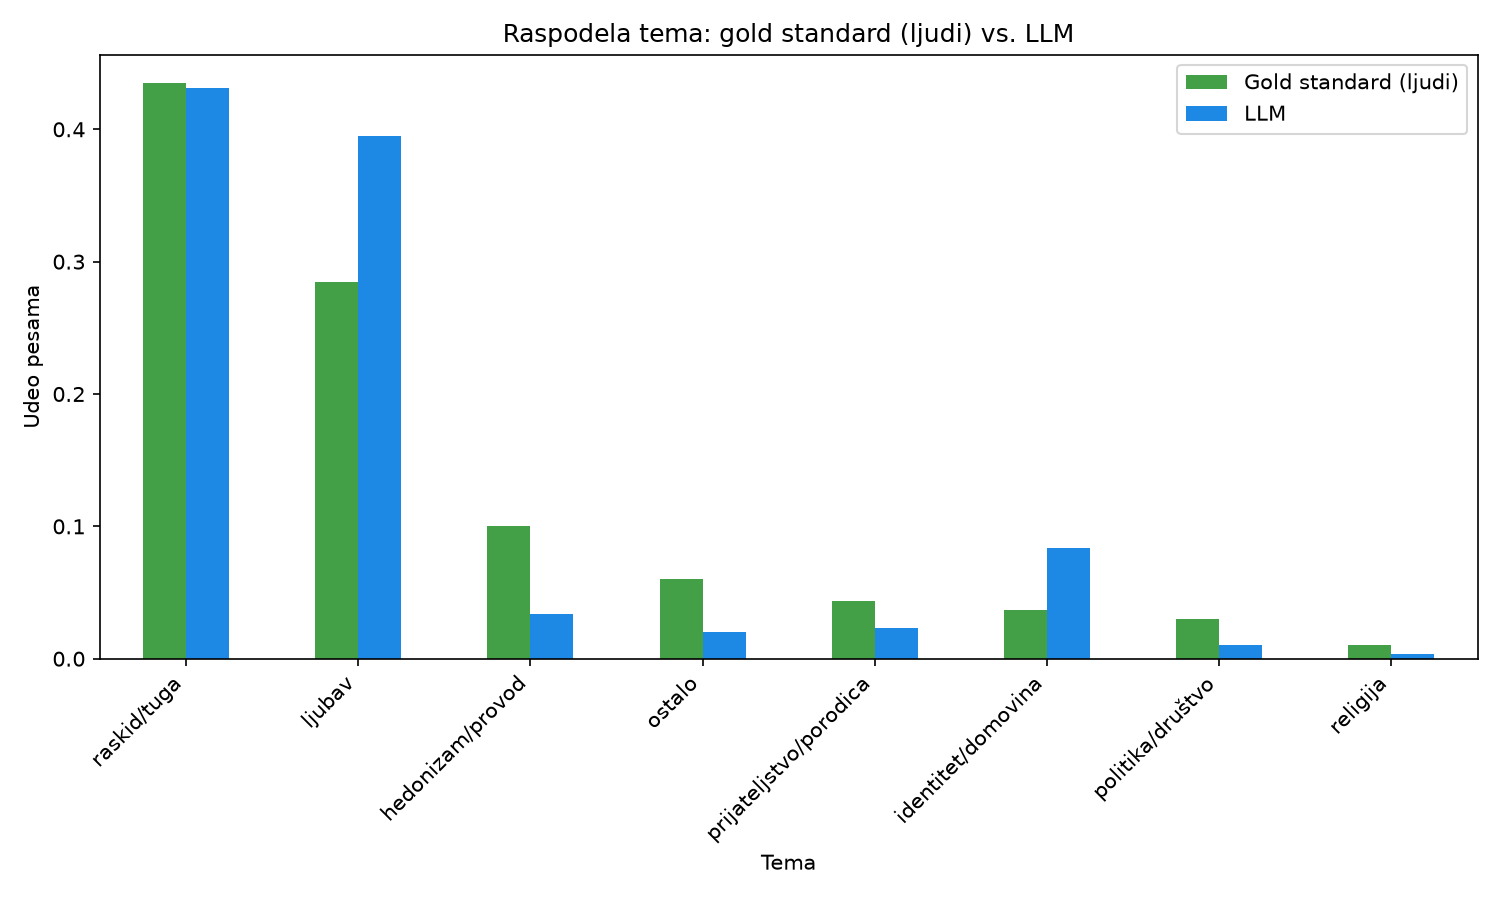

In [15]:
display(Image(filename=str(FIGURES_DIR / "gold_vs_llm_theme_comparison.png")))

### Unakrsna tabela tema (red = gold standard, kolona = LLM)

In [16]:
display(pd.crosstab(gold_theme_n, llm_theme_n))

llm_theme,hedonizam/provod,identitet/domovina,ljubav,ostalo,politika/drustvo,prijateljstvo/porodica,raskid/tuga,religija
gold_theme,,,,,,,,
hedonizam/provod,5,4,18,0,0,0,3,0
identitet/domovina,1,7,2,0,0,1,0,0
ljubav,2,2,58,0,0,1,22,0
ostalo,1,3,3,5,0,0,6,0
politika/drustvo,0,4,2,1,2,0,0,0
prijateljstvo/porodica,1,3,2,0,0,4,3,0
raskid/tuga,0,2,33,0,0,1,94,0
religija,0,0,0,0,1,0,1,1


> **Tumačenje:** kappa (0.36–0.41) je niža od prostog slaganja (58.9%)
> zato što oduzima deo slaganja koji bi se desio čisto slučajno — kad
> obe strane najčešće biraju iste dominantne kategorije, "slučajno"
> slaganje je visoko samo po sebi. Unakrsna tabela pokazuje **gde**
> LLM greši: sistematski povlači pesme ka `ljubav`/`raskid-tuga`, čak i
> kad je gold standard izabrao ređu, specifičniju kategoriju
> (`hedonizam/provod`, `politika/društvo`).

<a id="9"></a>
## 9. Obrasci neslaganja — kvalitativna analiza

Pet imenovanih, konkretnim primerima potkrepljenih obrazaca zašto se
LLM i ljudi razilaze (potpuni opis u `docs/obrasci_neslaganja.md`):

| # | Obrazac | Kratak opis |
|---|---|---|
| 1 | Kategorijalno sažimanje nijanse | LLM interno "zna" da je emocija mešovita, gubi to pri prinudnom izboru jedne kategorije |
| 2 | Mešanje tona sa sadržajem | Melanholičan ton starijih balada čita se kao raskid, iako je sadržaj o postojanoj ljubavi |
| 3 | Žanrovska konvencija kao "zavisnost" | Sevdah/narodnjačka predanost ("ne mogu bez tebe") čita se kao patološka zavisnost, ne romantika |
| 4 | Hedonizam → ljubav | Flert/fizička privlačnost sistematski postaje šira kategorija "ljubav" |
| 5 | Satira → identitet | Indirektna društvena kritika (Zabranjeno pušenje stil) ne prepoznaje se kao "politika/društvo" |

In [17]:
try:
    interesting = pd.read_csv(REPORTS_DIR / "interesting_disagreements.csv")
    print(f"Ukupno izdvojenih zanimljivih slučajeva: {len(interesting)}\n")
    display(interesting[["tip_slucaja", "artist", "title", "gold_emotion", "llm_emotion"]].head(10))
except FileNotFoundError:
    print("Fajl je namerno van GitHub-a (sadrži isečke teksta pesama - autorska prava).")
    print("Pokreni lokalno: python src/llm/extract_interesting_disagreements.py")

Ukupno izdvojenih zanimljivih slučajeva: 111



,tip_slucaja,artist,title,gold_emotion,llm_emotion
0,emocija: mešano -> negativno,Rasta,Bili smo klinci (ft. Vice),mešano,negativno
1,emocija: pozitivno -> negativno,Severina,"Noću, danju",pozitivno,negativno
2,emocija: pozitivno -> negativno,Jelena Rozga,Prsti zapleteni (duet Klapa Rišpet),pozitivno,negativno
3,emocija: mešano -> negativno,Jelena Rozga,Sve se meni čini,mešano,negativno
4,emocija: pozitivno -> negativno,Jelena Rozga,"Ne pijem, ne pušim",pozitivno,negativno
5,emocija: pozitivno -> negativno,Dado Polumenta,Od vina si me opila,pozitivno,negativno
6,emocija: mešano -> negativno,Jelena Rozga,Ja znam dobro što mi je,mešano,negativno
7,emocija: pozitivno -> negativno,Nina Badrić,Ja za ljubav neću moliti,pozitivno,negativno
8,emocija: mešano -> negativno,Jelena Rozga,Ima nade (with Željko Samardžić),mešano,negativno
9,emocija: mešano -> negativno,Nina Badrić,Nebo,mešano,negativno


<a id="10"></a>
## 10. Analiza po dekadama

Finiji prikaz od tri glavna perioda — po dekadama. **Napomena:** dekada
je izvedena iz procenjene godine PO IZVOĐAČU, ne stvarne godine svake
pesme, pa se pojedine tačke (posebno 2000s, n=271, dominantno pop žanr)
moraju tumačiti sa oprezom — videti napomenu ispisanu direktno na MATTR
grafikonu ispod.

### 10.1 Zastupljenost žanrova kroz dekade — najjači nalaz ove sekcije

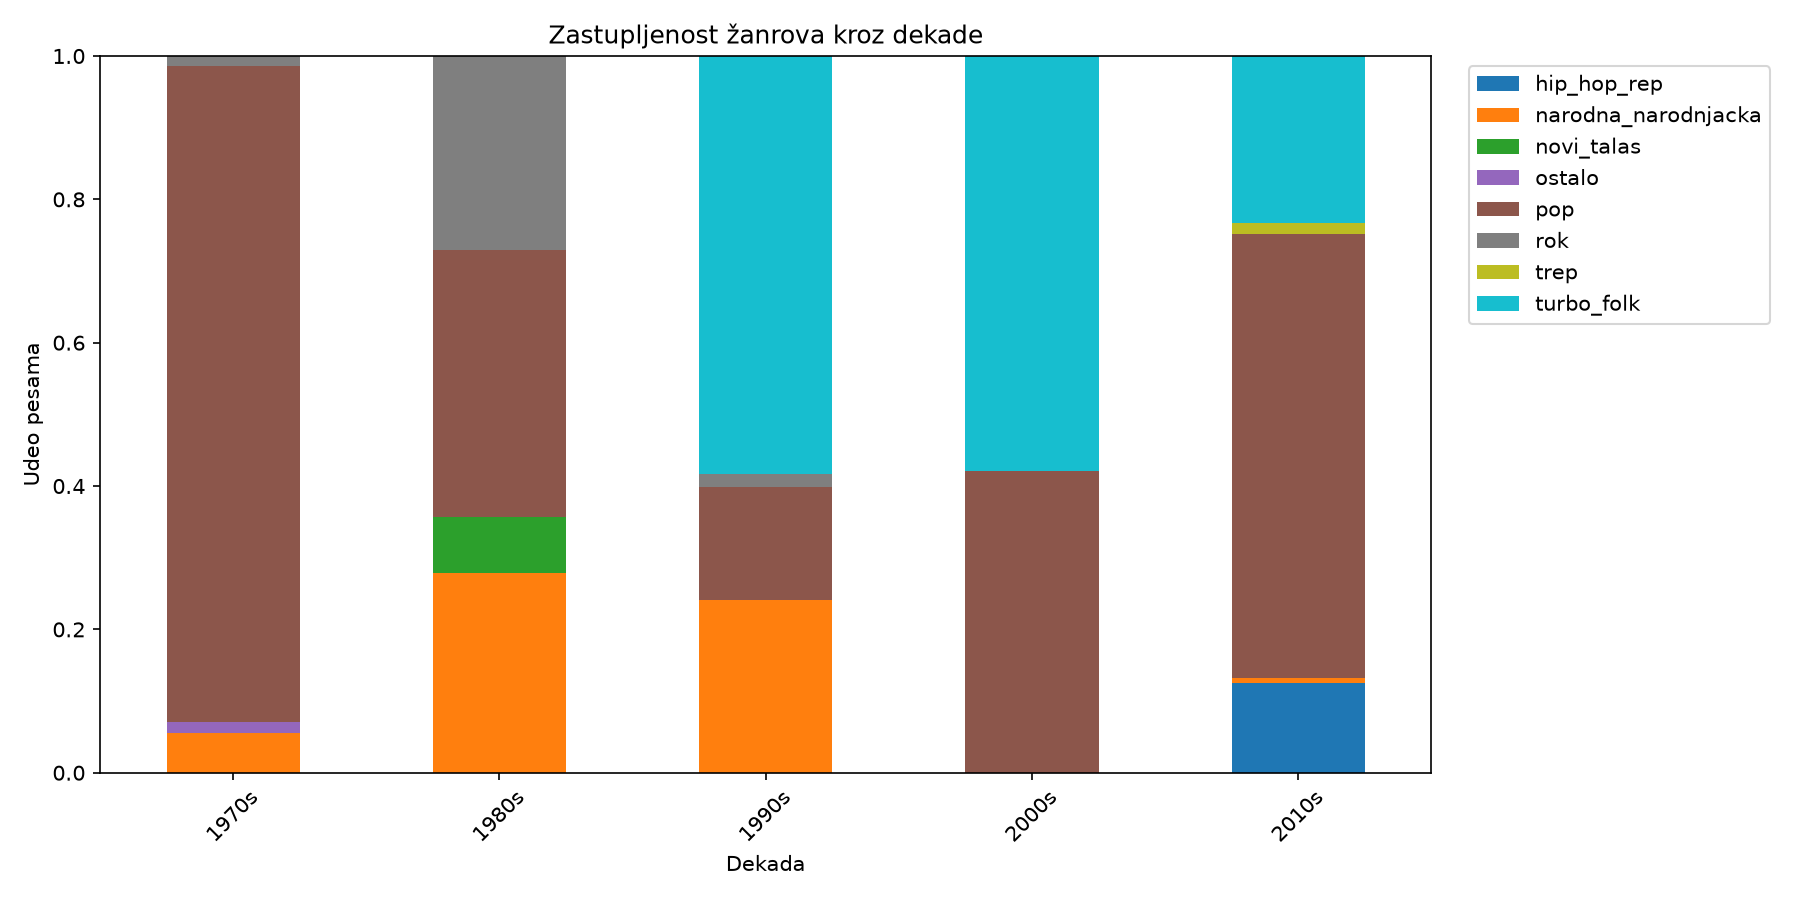

In [18]:
display(Image(filename=str(FIGURES_DIR / "genre_by_decade.png")))

> **Tumačenje:** direktna vizuelna potvrda istorijski poznate slike —
> novi talas postoji SAMO u 1980-im; turbo-folk eksplodira u 1990-im
> (skoro 60% svih pesama te dekade); hip-hop/rep i trep pojavljuju se
> TEK u 2010-im. Ovo se poklapa sa teorijskim okvirom iz literature
> (Gordy 1999, Kronja 2001) — grafikon daje kvantitativan dokaz za
> tvrdnje koje su u literaturi opisane kvalitativno.

### 10.2 Sentiment i leksička raznovrsnost kroz dekade

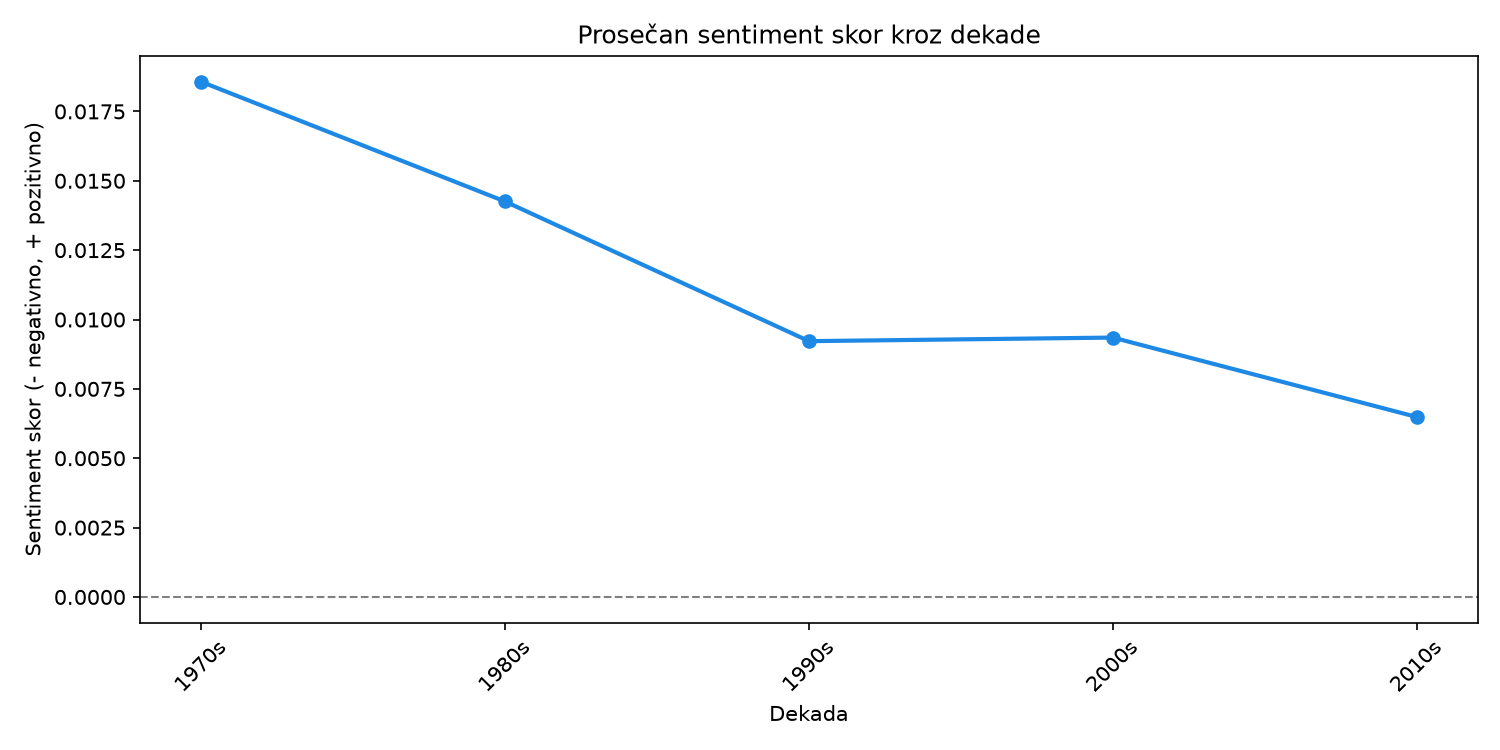

In [19]:
display(Image(filename=str(FIGURES_DIR / "sentiment_by_decade.png")))

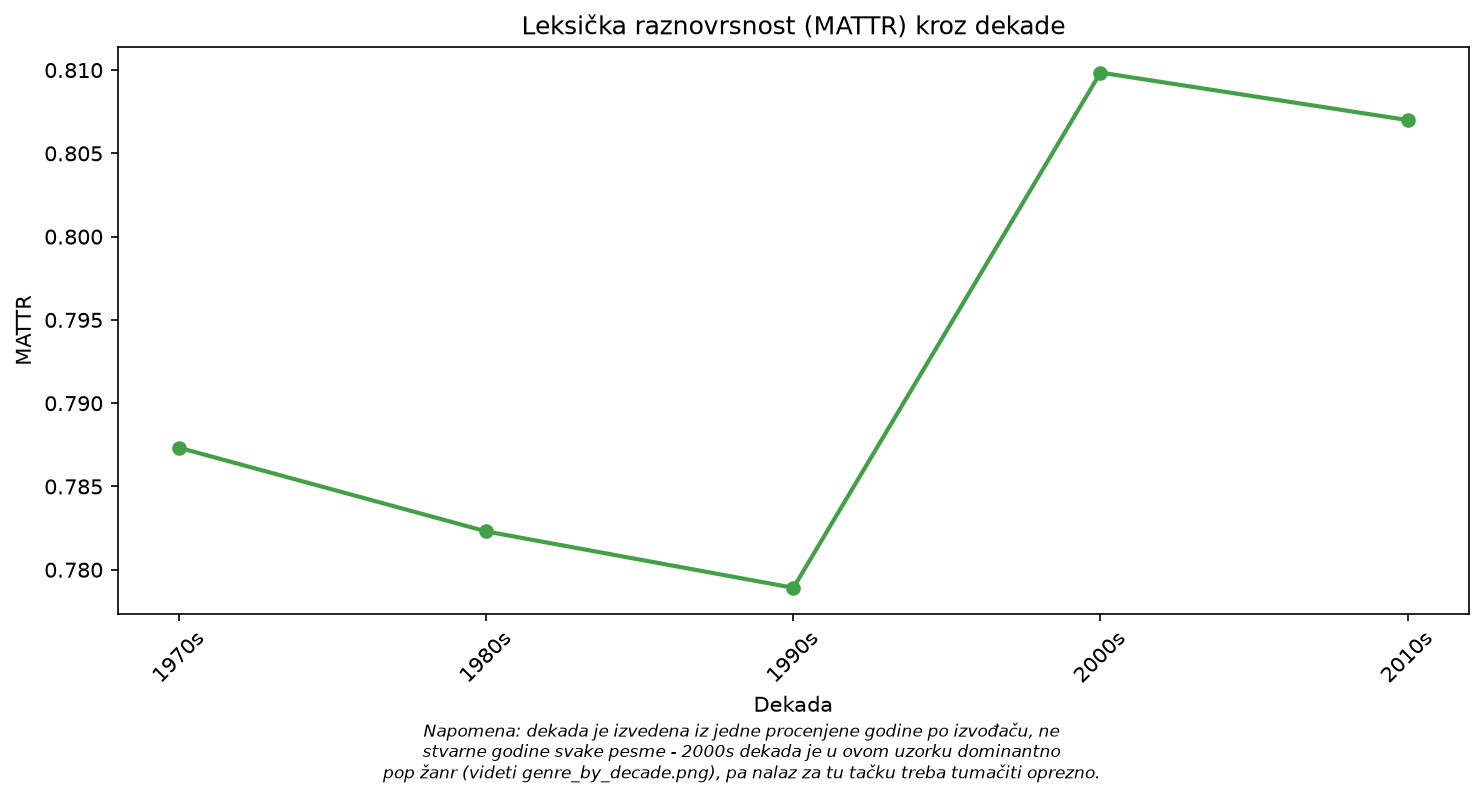

In [20]:
display(Image(filename=str(FIGURES_DIR / "mattr_by_decade.png")))

<a id="11"></a>
## 11. Rezime ključnih nalaza

**1. Tematska homogenost, potvrđena tri puta nezavisno**
TF-IDF, LDA i BERTopic se slažu: korpus dominantno govori o ljubavi/
raskidu. Prava žanrovska/istorijska razlika izranja tek u sekundarnom
sloju reči i u jasno izdvojenim "ostrvima" tema (Sarajevo/rat, hip-hop
kultura, dijalekat, religija).

**2. Istorijski tačna smena žanrova kroz dekade**
Novi talas (80-e) → turbo-folk (90-e) → hip-hop/trep (2010-e) — u
skladu sa teorijskim okvirom iz literature, sada i kvantitativno
potvrđeno.

**3. LLM klasifikacija — umereno pouzdana, sa objašnjivim obrascima grešaka**
Cohen's kappa 0.36–0.41 (slabo-umereno slaganje). Pet imenovanih
obrazaca objašnjava ZAŠTO — direktan, argumentovan odgovor na
istraživačko pitanje o pouzdanosti LLM alata na južnoslovenskim
jezicima (elaborat, poglavlje 2.4).

**4. Ograničenja transparentno dokumentovana, ne prećutana**
Trep praznina (8 pesama), NER isključen (torch/classla nekompatibilnost),
dekadna analiza osetljiva na uzorkovanje, prvobitna gold standard
anotacija otkrivena i ispravljena — svaka prepreka je dokumentovana kao
nalaz, ne sakrivena.

---

*Detaljna dokumentacija: `docs/napredak_projekta.md`,
`docs/obrasci_neslaganja.md`*